# LendingClub Interest Rate — Min-RMSE Notebook (Interpretable)

**Goal**: lowest validation RMSE we can hold while keeping the notebook readable as a final submission. Target: **val_RMSE ≤ 3.85**.

**Companion notebooks**
* `FINAL_SUBMISSION.ipynb` — 4-model + aux-grade champion (val ~3.83).
* `FINAL_SIMPLIFIED_MODEL_EXPLAINABILITY.ipynb` — minimal 2-model blend (val ~3.90, ~35 features).
* **This notebook** — middle ground. Adds back the 4 highest-ROI pieces of complexity from the champion.

**Design synthesized from**

| Source | Insight used here |
|---|---|
| Repo audit (`MODEL_DOCUMENTATION.md`, `production/features.py`, `reverse_engineer/v2/enrich_v2.py`) | Three confirmed interactions: `term_x_dti`, `fico_x_dti`, `fico_revol_interaction`. Aux-grade adds ~0.02 pp. |
| Data-driven interaction discovery (`outputs/simplification/interaction_candidates_ranked.csv`) | NO additional pairwise interaction beats the 3 confirmed ones on single-LGB. Stop searching; spend complexity budget elsewhere. |
| GBDT-regression research (Pargent 2022, OpenFE ICML 2023, APAR NeurIPS 2024) | `log1p(y)` for LGB+XGB on skewed targets, isotonic post-calibration on the OOF blend, sklearn 1.3+ TargetEncoder. |

**What changed vs the simplified notebook**

| Aspect | Simplified | Min-RMSE (this notebook) |
|---|---|---|
| Features | 35 | 35 + 11 aux-grade enrichment + 2 FICO×aux = **48** |
| Models | CB + LGB | **CB + LGB + XGB** |
| Target | raw `int_rate` | raw for CB; **log1p for LGB + XGB** |
| Tuning | cached CB + Optuna LGB (30 trials) | cached CB + Optuna LGB (40) + Optuna XGB (40) |
| Blend post-processing | none | **isotonic recalibration on OOF blend** |
| Submission | `FINAL_SIMPLIFIED_SUBMISSION.csv` | `FINAL_MIN_RMSE_SUBMISSION.csv` |
| Runtime | ~15-20 min | **~30-40 min** |
| Documented expected RMSE | ~3.90 | **~3.82-3.85** |

**Interpretability is preserved** by:
* Staying under 50 features.
* Three GBDT learners (no neural nets, no stacking meta-learners).
* Aux-grade outputs are explicitly labelled `aux_grade_prob_*` so a SHAP reader can identify them.
* Isotonic recalibration is a single monotone 1-D transform — easy to visualize.

**Reproducibility**: same `RANDOM_STATE = 6604`, same 80/20 split, same 5-fold KFold, leak-safe per-fold target encoding, leak-safe per-fold log1p inversion.

## 1. Imports and paths

In [1]:
import json
import warnings
from pathlib import Path
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, train_test_split
from sklearn.isotonic import IsotonicRegression
from sklearn.inspection import permutation_importance
from scipy.optimize import minimize

from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from lightgbm import LGBMRegressor, early_stopping as lgb_es, log_evaluation as lgb_log
from xgboost import XGBRegressor

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'true data'
ARCHIVE_LC_TRAIN = PROJECT_ROOT / 'achive_data' / 'archive' / 'LC_train.csv'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'min_rmse'
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 6604
N_FOLDS = 5
HOLDOUT_FRAC = 0.20
N_TRIALS_LGB = 40
N_TRIALS_XGB = 40

print('Project root :', PROJECT_ROOT)
print('Data dir     :', DATA_DIR)
print('Archive      :', ARCHIVE_LC_TRAIN)
print('Output dir   :', OUT_DIR)
print(f'Seed={RANDOM_STATE}, n_folds={N_FOLDS}, n_trials LGB={N_TRIALS_LGB}, n_trials XGB={N_TRIALS_XGB}')

Project root : c:\Users\liula\Documents\applied ai\project 1
Data dir     : c:\Users\liula\Documents\applied ai\project 1\true data
Archive      : c:\Users\liula\Documents\applied ai\project 1\achive_data\archive\LC_train.csv
Output dir   : c:\Users\liula\Documents\applied ai\project 1\outputs\min_rmse
Seed=6604, n_folds=5, n_trials LGB=40, n_trials XGB=40


## 2. Load `true data/` and drop `loan_status`

`loan_status` is post-origination outcome data — drop on read. Eight columns arrive as strings with literal `"NA"`; coerce to float at read.

In [2]:
STRING_NUMERIC_COLS = [
    'dti', 'revol_util', 'all_util', 'mo_sin_old_il_acct',
    'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc',
    'mths_since_recent_inq', 'tot_cur_bal',
]
DT_OVERRIDES = {c: 'float64' for c in STRING_NUMERIC_COLS}

train_raw = pd.read_csv(DATA_DIR / 'LC_train.csv', na_values=['NA'],
                       dtype=DT_OVERRIDES, low_memory=False)
test_raw  = pd.read_csv(DATA_DIR / 'LC_test.csv',  na_values=['NA'],
                       dtype=DT_OVERRIDES, low_memory=False)

train_raw = train_raw.drop(columns=['loan_status'])
test_raw  = test_raw.drop(columns=['loan_status'])

print('train_raw:', train_raw.shape)
print('test_raw :', test_raw.shape)
print('target stats (int_rate):')
print(train_raw['int_rate'].describe().round(2))

train_raw: (100000, 38)
test_raw : (10000, 38)
target stats (int_rate):
count    100000.00
mean         12.95
std           5.26
min           6.46
25%           8.19
50%          11.71
75%          16.12
max          30.99
Name: int_rate, dtype: float64


## 3. Feature engineering — reduced set (35 columns)

Same FE as the simplified notebook. The interaction-discovery experiment in `outputs/simplification/interaction_candidates_ranked.csv` confirmed that no additional pairwise interaction reduces single-LGB RMSE beyond the three already kept (`term_x_dti`, `fico_x_dti`, `fico_revol_interaction`). The complexity budget is better spent on aux-grade enrichment + a third base learner, both added below.

In [3]:
EMP_LENGTH_MAP = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10,
}

def engineer_reduced(df):
    out = df.copy()
    # FICO core
    out['fico'] = (out['fico_range_low'] + out['fico_range_high']) / 2
    out['fico_band'] = pd.cut(out['fico'], bins=[-np.inf, 660, 690, 720, 760, np.inf],
                              labels=False).astype('Int64')
    out['fico_above_prime'] = (out['fico'] >= 720).astype('int8')
    # Loan structure
    out['term_months'] = (out['term'].astype('string').str.extract(r'(\d+)', expand=False)
                          .astype('Int64'))
    out['installment_proxy'] = out['loan_amnt'] / out['term_months'].astype('float64')
    out['loan_to_income'] = out['loan_amnt'] / out['annual_inc'].replace(0, np.nan)
    out['payment_to_income'] = out['installment_proxy'] / (out['annual_inc'].replace(0, np.nan) / 12)
    # Utilisation
    out['util_max'] = np.maximum(out['all_util'].fillna(0), out['revol_util'].fillna(0))
    # Three confirmed interactions
    out['term_x_dti']             = out['term_months'].astype('float64') * out['dti']
    out['fico_x_dti']             = out['fico'] * out['dti']
    out['fico_revol_interaction'] = out['fico'] * out['revol_util']
    # Tenure
    out['credit_file_age_yrs'] = out['mo_sin_old_rev_tl_op'] / 12.0
    out['inq_per_credit_age']  = (out['inq_last_12m'].fillna(0) /
                                  (out['credit_file_age_yrs'].fillna(0) + 1))
    # Monetary log-tails
    out['log1p_annual_inc'] = np.log1p(out['annual_inc'].clip(lower=0))
    out['log1p_loan_amnt']  = np.log1p(out['loan_amnt'].clip(lower=0))
    out['log1p_revol_bal']  = np.log1p(out['revol_bal'].clip(lower=0))
    # High-cardinality cleanup
    out['zip3'] = out['zip_code'].astype('string').str.extract(r'(\d{3})', expand=False)
    out['emp_length_num'] = out['emp_length'].map(EMP_LENGTH_MAP)
    drop = ['fico_range_low', 'fico_range_high', 'term', 'emp_length',
            'title', 'zip_code', 'emp_title']
    return out.drop(columns=[c for c in drop if c in out.columns])


train_fe = engineer_reduced(train_raw)
test_fe  = engineer_reduced(test_raw)

test_ids = test_fe['ID'].copy()
test_fe = test_fe.drop(columns=['ID'])
y = train_fe['int_rate'].values.astype(np.float64)
X = train_fe.drop(columns=['int_rate'])

REDUCED_FEATURES = [
    'fico', 'fico_band', 'fico_above_prime',
    'dti', 'revol_util', 'all_util', 'util_max',
    'term_months', 'loan_amnt', 'installment_proxy',
    'loan_to_income', 'payment_to_income', 'log1p_loan_amnt',
    'annual_inc', 'revol_bal', 'tot_cur_bal', 'total_bal_ex_mort',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op',
    'mths_since_rcnt_il', 'mths_since_recent_bc', 'mths_since_recent_inq',
    'credit_file_age_yrs',
    'term_x_dti', 'fico_x_dti', 'fico_revol_interaction',
    'inq_fi', 'inq_per_credit_age',
    'addr_state', 'purpose', 'application_type', 'zip3',
    'log1p_annual_inc', 'log1p_revol_bal', 'emp_length_num',
]
present = [c for c in REDUCED_FEATURES if c in X.columns]
X = X[present].copy()
test_fe = test_fe[present].copy()

print(f'Reduced X shape:    {X.shape}')
print(f'Reduced test shape: {test_fe.shape}')

Reduced X shape:    (100000, 35)
Reduced test shape: (10000, 35)


## 4. Auxiliary grade classifier — reverse-engineering the missing `grade`

LendingClub's internal `grade` column is the single biggest predictor of `int_rate` (Phil Fed: ~90% of variance). The `true data/` slice has it stripped, but the historical `achive_data/archive/LC_train.csv` *does* contain `grade`.

We train one CatBoost classifier on the archive (~5 min) and predict 7 grade probabilities on the true-data train+test rows. The model never sees `int_rate` (only `grade`), and the archive's row sample is disjoint from the true-data slice — so there is no target leakage even though both files are LendingClub-sourced.

This single trick contributes ~0.02 pp of RMSE lift documented in `MODEL_DOCUMENTATION.md` §7. We keep its outputs explicitly labelled `aux_grade_prob_*` so the explainability layer downstream can clearly distinguish them.

In [4]:
COMMON_FEATURES = [
    'addr_state', 'annual_inc', 'application_type', 'chargeoff_within_12_mths',
    'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'emp_length', 'emp_title',
    'home_ownership', 'loan_amnt', 'mo_sin_old_rev_tl_op', 'mort_acc', 'open_acc',
    'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util',
    'term', 'title', 'total_acc', 'verification_status', 'zip_code',
]
GRADE_CLASSES = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

print('Loading archive LC_train.csv (has grade)...')
arch = pd.read_csv(ARCHIVE_LC_TRAIN, na_values=['NA', 'n/a'], low_memory=False)
if 'revol_util' in arch.columns and arch['revol_util'].dtype == object:
    arch['revol_util'] = pd.to_numeric(arch['revol_util'].astype(str).str.rstrip('%'),
                                         errors='coerce')
arch = arch.dropna(subset=['grade']).reset_index(drop=True)
arch_X = arch[[c for c in COMMON_FEATURES if c in arch.columns]].copy()
arch_y = arch['grade']
print(f'archive: {arch.shape}  grade counts: {arch_y.value_counts().to_dict()}')

aux_cat_cols = [c for c in ['addr_state', 'application_type', 'emp_length', 'emp_title',
                            'home_ownership', 'purpose', 'term', 'title',
                            'verification_status', 'zip_code'] if c in arch_X.columns]

def cb_prepare(df):
    df = df.copy()
    for c in aux_cat_cols:
        if c in df.columns:
            df[c] = df[c].astype('string').fillna('Missing')
    for c in df.columns:
        if c not in aux_cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, [df.columns.get_loc(c) for c in aux_cat_cols if c in df.columns]


print('\nTraining CatBoost grade classifier on archive (~5 min)...')
t = time()
arch_Xp, arch_cat_idx = cb_prepare(arch_X)
aux_model = CatBoostClassifier(
    iterations=1500, depth=7, learning_rate=0.05,
    l2_leaf_reg=3.0, loss_function='MultiClass', eval_metric='MultiClass',
    random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
    early_stopping_rounds=100,
)
Xt, Xv, yt, yv = train_test_split(arch_Xp, arch_y, test_size=0.10,
                                    random_state=RANDOM_STATE, stratify=arch_y)
aux_model.fit(Xt, yt, cat_features=arch_cat_idx, eval_set=(Xv, yv), verbose=False)
print(f'  aux model trained in {time()-t:.0f}s')

Loading archive LC_train.csv (has grade)...
archive: (100000, 39)  grade counts: {'B': 32399, 'C': 21838, 'A': 21564, 'D': 13922, 'E': 6801, 'F': 2696, 'G': 780}

Training CatBoost grade classifier on archive (~5 min)...
  aux model trained in 1344s


### Apply aux model to true train + test → 11 enrichment columns

In [5]:
def apply_aux(df, true_raw):
    """Build aux features by routing the raw true-data row through the aux model.

    `true_raw` is the un-engineered DataFrame (still has emp_title, etc.) so that
    the aux model sees its training feature names. `df` is the engineered frame
    we will *attach the aux columns to*."""
    aux_feature_names = list(aux_model.feature_names_)
    src = true_raw.copy()
    for c in aux_feature_names:
        if c not in src.columns:
            src[c] = np.nan
    src = src[aux_feature_names].copy()
    src_p, _ = cb_prepare(src)
    proba = aux_model.predict_proba(src_p)
    classes = list(aux_model.classes_)
    if classes != GRADE_CLASSES:
        idx = [classes.index(g) for g in GRADE_CLASSES]
        proba = proba[:, idx]
    return proba


# Need to align by row order with X / test_fe
train_aux = apply_aux(X, train_raw.drop(columns=['int_rate']))
test_aux  = apply_aux(test_fe, test_raw.drop(columns=['ID']))

# Append 7 grade-prob columns + argmax + max-prob
for j, g in enumerate(GRADE_CLASSES):
    X[f'aux_grade_prob_{g}']       = train_aux[:, j]
    test_fe[f'aux_grade_prob_{g}'] = test_aux[:, j]
X['aux_grade_argmax']      = train_aux.argmax(axis=1) + 1
test_fe['aux_grade_argmax'] = test_aux.argmax(axis=1) + 1
X['aux_grade_max_prob']      = train_aux.max(axis=1)
test_fe['aux_grade_max_prob'] = test_aux.max(axis=1)

# 2 FICO × aux interactions — the only aux-grade-derived features the repo
# evidence suggests are worth keeping (the other 6 from enrich_v2 are marginal).
X['fico_x_aux_argmax']       = X['fico'] * X['aux_grade_argmax']
test_fe['fico_x_aux_argmax'] = test_fe['fico'] * test_fe['aux_grade_argmax']
X['fico_x_aux_max_prob']       = X['fico'] * X['aux_grade_max_prob']
test_fe['fico_x_aux_max_prob'] = test_fe['fico'] * test_fe['aux_grade_max_prob']

print(f'Features after aux enrichment: {X.shape[1]}  (added 11 columns)')
print(f'Aux grade argmax counts (train): {pd.Series(X["aux_grade_argmax"]).value_counts().sort_index().to_dict()}')

Features after aux enrichment: 46  (added 11 columns)
Aux grade argmax counts (train): {1: 22140, 2: 47024, 3: 16710, 4: 6846, 5: 6174, 6: 720, 7: 386}


## 5. 80/20 split + leak-safe target encoding helpers

* Same 80/20 random hold-out as the simplified and champion notebooks (`random_state=6604`).
* Smoothed K-fold OOF target encoding (m=20) for `addr_state`, `purpose`, `zip3`.
* `emp_title` was dropped from the reduced FE so its TE is also dropped.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=HOLDOUT_FRAC,
                                                   random_state=RANDOM_STATE)
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
print('X_train:', X_train.shape)
print('X_val  :', X_val.shape)
print('X_test :', test_fe.shape)

NATIVE_CAT = ['application_type', 'purpose']
TE_CAT     = ['addr_state', 'purpose', 'zip3']
ALL_CAT    = list(set(NATIVE_CAT + TE_CAT))
TARGET_ENC_M = 20.0


def smoothed_te(train_col, target, val_col=None, test_col=None, folds=5,
                seed=RANDOM_STATE):
    global_mean = float(np.nanmean(target))
    val_enc = test_enc = None
    if val_col is not None or test_col is not None:
        stats = pd.DataFrame({'cat': train_col.values, 'y': target}).groupby('cat')['y'].agg(['mean', 'count'])
        stats['enc'] = (stats['mean']*stats['count'] + global_mean*TARGET_ENC_M) / (stats['count']+TARGET_ENC_M)
        mapping = stats['enc'].to_dict()
        val_enc  = val_col.map(mapping).fillna(global_mean).values if val_col is not None else None
        test_enc = test_col.map(mapping).fillna(global_mean).values if test_col is not None else None
    train_enc = np.full(len(train_col), global_mean, dtype=np.float64)
    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)
    for tr, va in kf.split(train_col):
        inner = pd.DataFrame({'cat': train_col.values[tr], 'y': target[tr]}).groupby('cat')['y'].agg(['mean', 'count'])
        inner['enc'] = (inner['mean']*inner['count'] + global_mean*TARGET_ENC_M) / (inner['count']+TARGET_ENC_M)
        train_enc[va] = pd.Series(train_col.values[va]).map(inner['enc'].to_dict()).fillna(global_mean).values
    return train_enc, val_enc, test_enc


def add_te(Xtr, ytr, Xva, Xte):
    Xtr, Xva, Xte = Xtr.copy(), Xva.copy(), Xte.copy()
    for c in TE_CAT:
        if c not in Xtr.columns:
            continue
        tr_e, va_e, te_e = smoothed_te(
            Xtr[c].astype(str), ytr,
            Xva[c].astype(str) if Xva is not None else None,
            Xte[c].astype(str) if Xte is not None else None,
        )
        Xtr[f'{c}_te'] = tr_e
        if va_e is not None:
            Xva[f'{c}_te'] = va_e
        if te_e is not None:
            Xte[f'{c}_te'] = te_e
    return Xtr, Xva, Xte


def prep_cb(df):
    df = df.copy()
    cat_cols = [c for c in ALL_CAT if c in df.columns]
    for c in cat_cols:
        df[c] = df[c].astype('string').fillna('Missing')
    cat_idx = [df.columns.get_loc(c) for c in cat_cols]
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, cat_idx


def prep_lgb(df, cat_dtypes=None):
    df = df.copy()
    cat_cols = [c for c in ALL_CAT if c in df.columns]
    for c in cat_cols:
        s = df[c].astype('string').fillna('Missing')
        df[c] = s.astype(cat_dtypes[c]) if cat_dtypes and c in cat_dtypes else s.astype('category')
    for c in df.columns:
        if c not in cat_cols:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return df, cat_cols


def build_cat_dtypes(df):
    return {c: pd.CategoricalDtype(categories=pd.Index(df[c].astype('string').fillna('Missing').unique()))
            for c in ALL_CAT if c in df.columns}


# log1p / expm1 helpers for the target transform on LGB and XGB
def log1p_y(y):  return np.log1p(y)
def expm1_y(y):  return np.expm1(y)

print('Helpers ready.')

X_train: (80000, 46)
X_val  : (20000, 46)
X_test : (10000, 46)
Helpers ready.


## 6. Cached CatBoost hyperparameters

Production v2's Optuna-tuned CB params (100 trials, ~1.5 hr). Near-optimal across feature-set sizes — we reuse.

In [7]:
CB_PARAMS = {
    'learning_rate': 0.034266751541500245,
    'depth': 7,
    'l2_leaf_reg': 0.9758040518945117,
    'random_strength': 4.906296660542921,
    'bagging_temperature': 0.14995979808622192,
    'border_count': 197,
}
print('CB_PARAMS:', CB_PARAMS)

CB_PARAMS: {'learning_rate': 0.034266751541500245, 'depth': 7, 'l2_leaf_reg': 0.9758040518945117, 'random_strength': 4.906296660542921, 'bagging_temperature': 0.14995979808622192, 'border_count': 197}


## 7. Optuna Bayesian search — LightGBM and XGBoost on the enriched feature set

40 TPE trials each, inner 85/15 split. Both are fit with `log1p(int_rate)` as the target — this is the single biggest structural change vs the simplified notebook and is the technique with the most robust GBDT-on-skewed-regression evidence in the literature (APAR NeurIPS 2024).

CatBoost stays on raw `int_rate` because (a) its native loss handles skew well and (b) keeping it on the raw scale increases decorrelation between the three base learners, which the SLSQP blend exploits.

In [8]:
# Inner 85/15 split from the 80% train
inner_tr, inner_va = train_test_split(
    np.arange(len(X_train)), test_size=0.15, random_state=RANDOM_STATE,
)
Xtr_inner = X_train.iloc[inner_tr].reset_index(drop=True)
Xva_inner = X_train.iloc[inner_va].reset_index(drop=True)
ytr_inner = y_train[inner_tr]
yva_inner = y_train[inner_va]

Xtr_inner_te, Xva_inner_te, _ = add_te(Xtr_inner, ytr_inner, Xva_inner, X_train.iloc[:0])

cat_dt_inner = build_cat_dtypes(Xtr_inner_te)
Xtr_lgb_inner, lgb_cat_cols_inner = prep_lgb(Xtr_inner_te, cat_dt_inner)
Xva_lgb_inner, _ = prep_lgb(Xva_inner_te, cat_dt_inner)

# Train both LGB and XGB on log1p target; evaluate after expm1 inversion
ytr_inner_log = log1p_y(ytr_inner)


def lgb_objective(trial):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.015, 0.08, log=True),
        'num_leaves':         trial.suggest_int('num_leaves', 31, 256),
        'max_depth':          trial.suggest_int('max_depth', -1, 12),
        'min_child_samples':  trial.suggest_int('min_child_samples', 20, 200),
        'feature_fraction':   trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':   trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':       1,
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'n_estimators':       4000,
        'objective': 'regression', 'metric': 'rmse',
        'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1,
    }
    m = LGBMRegressor(**params)
    m.fit(Xtr_lgb_inner, ytr_inner_log,
          eval_set=[(Xva_lgb_inner, log1p_y(yva_inner))],
          categorical_feature=lgb_cat_cols_inner,
          callbacks=[lgb_es(100, verbose=False), lgb_log(0)])
    pred = expm1_y(m.predict(Xva_lgb_inner))
    return float(np.sqrt(mean_squared_error(yva_inner, pred)))


def xgb_objective(trial):
    params = {
        'learning_rate':     trial.suggest_float('learning_rate', 0.015, 0.08, log=True),
        'max_depth':          trial.suggest_int('max_depth', 4, 12),
        'min_child_weight':   trial.suggest_int('min_child_weight', 1, 60),
        'subsample':          trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':   trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'colsample_bylevel':  trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'reg_alpha':          trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda':         trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'gamma':              trial.suggest_float('gamma', 1e-3, 5.0, log=True),
        'n_estimators':       4000,
        'objective': 'reg:squarederror', 'tree_method': 'hist',
        'enable_categorical': True, 'random_state': RANDOM_STATE, 'n_jobs': -1,
        'early_stopping_rounds': 100,
    }
    m = XGBRegressor(**params)
    m.fit(Xtr_lgb_inner, ytr_inner_log,
          eval_set=[(Xva_lgb_inner, log1p_y(yva_inner))],
          verbose=False)
    pred = expm1_y(m.predict(Xva_lgb_inner))
    return float(np.sqrt(mean_squared_error(yva_inner, pred)))


print(f'[Optuna] LGB ({N_TRIALS_LGB} trials)...')
t = time()
study_lgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE, multivariate=True, warn_independent_sampling=False),
    pruner=MedianPruner(n_warmup_steps=10),
    study_name='lgb_min_rmse',
)
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS_LGB, show_progress_bar=True)
LGB_PARAMS = dict(study_lgb.best_params)
LGB_PARAMS.update({'n_estimators': 4000, 'bagging_freq': 1,
                    'objective': 'regression', 'metric': 'rmse',
                    'random_state': RANDOM_STATE, 'verbose': -1, 'n_jobs': -1})
print(f'  best inner RMSE (log target): {study_lgb.best_value:.4f}  ({time()-t:.0f}s)')
print(f'  best params: {study_lgb.best_params}')

print(f'\n[Optuna] XGB ({N_TRIALS_XGB} trials)...')
t = time()
study_xgb = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=RANDOM_STATE, multivariate=True, warn_independent_sampling=False),
    pruner=MedianPruner(n_warmup_steps=10),
    study_name='xgb_min_rmse',
)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)
XGB_PARAMS = dict(study_xgb.best_params)
XGB_PARAMS.update({'n_estimators': 4000, 'objective': 'reg:squarederror',
                    'tree_method': 'hist', 'enable_categorical': True,
                    'random_state': RANDOM_STATE, 'n_jobs': -1,
                    'early_stopping_rounds': 100})
print(f'  best inner RMSE (log target): {study_xgb.best_value:.4f}  ({time()-t:.0f}s)')
print(f'  best params: {study_xgb.best_params}')

[Optuna] LGB (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]

  best inner RMSE (log target): 3.9495  (782s)
  best params: {'learning_rate': 0.024686550631024647, 'num_leaves': 115, 'max_depth': 7, 'min_child_samples': 73, 'feature_fraction': 0.5197702179187468, 'bagging_fraction': 0.756871785516511, 'reg_alpha': 0.6083465298838759, 'reg_lambda': 2.1288532146635792}

[Optuna] XGB (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]

  best inner RMSE (log target): 3.9197  (1107s)
  best params: {'learning_rate': 0.03344006364024286, 'max_depth': 9, 'min_child_weight': 15, 'subsample': 0.7826099217368702, 'colsample_bytree': 0.7367092054999357, 'colsample_bylevel': 0.8250101124189009, 'reg_alpha': 4.042487520704864, 'reg_lambda': 0.012676447847401311, 'gamma': 0.06153788179600164}


## 8. 5-fold OOF training — CatBoost (raw target) + LightGBM (log1p) + XGBoost (log1p)

For each fold:
1. Rebuild leak-safe per-fold target encodings.
2. Fit CB on raw `int_rate`; fit LGB and XGB on `log1p(int_rate)`.
3. Invert `expm1` on LGB and XGB predictions before evaluation and before blending — so all three base learners produce outputs on the same interest-rate scale.
4. Aggregate OOF, val, and test predictions.

In [9]:
n_tr, n_va, n_te = len(X_train), len(X_val), len(test_fe)
BASES = ['cb', 'lgb', 'xgb']
oof   = {b: np.zeros(n_tr) for b in BASES}
val_p = {b: np.zeros(n_va) for b in BASES}
te_p  = {b: np.zeros(n_te) for b in BASES}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
fold_rmses = []
total_t = time()

for fold_id, (tr_idx, va_idx) in enumerate(kf.split(X_train)):
    t_fold = time()
    Xtr, Xva = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    ytr, yva = y_train[tr_idx], y_train[va_idx]
    ytr_log = log1p_y(ytr)

    Xtr_te, Xva_te, Xte_te = add_te(Xtr, ytr, Xva, test_fe)
    _, Xval_te, _          = add_te(Xtr, ytr, X_val, test_fe)

    fold_results = {}

    # --- CatBoost on raw target ---
    t = time()
    Xtr_cb, cat_idx = prep_cb(Xtr_te)
    Xva_cb, _       = prep_cb(Xva_te)
    Xval_cb, _      = prep_cb(Xval_te)
    Xte_cb, _       = prep_cb(Xte_te)
    cb = CatBoostRegressor(**CB_PARAMS,
                            iterations=3000, loss_function='RMSE', eval_metric='RMSE',
                            random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
                            early_stopping_rounds=120)
    cb.fit(Xtr_cb, ytr, cat_features=cat_idx, eval_set=(Xva_cb, yva), verbose=False)
    oof['cb'][va_idx] = cb.predict(Xva_cb)
    val_p['cb'] += cb.predict(Xval_cb) / N_FOLDS
    te_p['cb']  += cb.predict(Xte_cb)  / N_FOLDS
    fold_results['cb'] = float(np.sqrt(mean_squared_error(yva, oof['cb'][va_idx])))
    print(f'  fold {fold_id+1} cb  ({time()-t:5.0f}s, RMSE={fold_results["cb"]:.4f})')

    # --- LightGBM on log1p(target) ---
    t = time()
    cat_dt = build_cat_dtypes(Xtr_te)
    Xtr_lgb, cat_cols = prep_lgb(Xtr_te, cat_dt)
    Xva_lgb, _        = prep_lgb(Xva_te, cat_dt)
    Xval_lgb, _       = prep_lgb(Xval_te, cat_dt)
    Xte_lgb, _        = prep_lgb(Xte_te, cat_dt)
    lgb_m = LGBMRegressor(**LGB_PARAMS)
    lgb_m.fit(Xtr_lgb, ytr_log, eval_set=[(Xva_lgb, log1p_y(yva))],
              categorical_feature=cat_cols,
              callbacks=[lgb_es(120, verbose=False), lgb_log(0)])
    # Invert log1p before recording predictions on the rate scale
    oof['lgb'][va_idx] = expm1_y(lgb_m.predict(Xva_lgb))
    val_p['lgb'] += expm1_y(lgb_m.predict(Xval_lgb)) / N_FOLDS
    te_p['lgb']  += expm1_y(lgb_m.predict(Xte_lgb))  / N_FOLDS
    fold_results['lgb'] = float(np.sqrt(mean_squared_error(yva, oof['lgb'][va_idx])))
    print(f'  fold {fold_id+1} lgb ({time()-t:5.0f}s, RMSE={fold_results["lgb"]:.4f})')

    # --- XGBoost on log1p(target) ---
    t = time()
    Xtr_xgb, _  = prep_lgb(Xtr_te, cat_dt)
    Xva_xgb, _  = prep_lgb(Xva_te, cat_dt)
    Xval_xgb, _ = prep_lgb(Xval_te, cat_dt)
    Xte_xgb, _  = prep_lgb(Xte_te, cat_dt)
    xgb_m = XGBRegressor(**XGB_PARAMS)
    xgb_m.fit(Xtr_xgb, ytr_log, eval_set=[(Xva_xgb, log1p_y(yva))], verbose=False)
    oof['xgb'][va_idx] = expm1_y(xgb_m.predict(Xva_xgb))
    val_p['xgb'] += expm1_y(xgb_m.predict(Xval_xgb)) / N_FOLDS
    te_p['xgb']  += expm1_y(xgb_m.predict(Xte_xgb))  / N_FOLDS
    fold_results['xgb'] = float(np.sqrt(mean_squared_error(yva, oof['xgb'][va_idx])))
    print(f'  fold {fold_id+1} xgb ({time()-t:5.0f}s, RMSE={fold_results["xgb"]:.4f})')

    fold_rmses.append(fold_results)
    print(f'  -> fold {fold_id+1}/{N_FOLDS} total: {time()-t_fold:.0f}s')

print(f'\nTotal OOF training: {time()-total_t:.0f}s')

  fold 1 cb  (  372s, RMSE=3.8756)
  fold 1 lgb (   10s, RMSE=3.9485)
  fold 1 xgb (   12s, RMSE=3.9200)
  -> fold 1/5 total: 394s
  fold 2 cb  (  321s, RMSE=3.9384)
  fold 2 lgb (    9s, RMSE=4.0369)
  fold 2 xgb (   11s, RMSE=4.0112)
  -> fold 2/5 total: 341s
  fold 3 cb  (  254s, RMSE=3.9033)
  fold 3 lgb (    8s, RMSE=3.9757)
  fold 3 xgb (   12s, RMSE=3.9364)
  -> fold 3/5 total: 274s
  fold 4 cb  (  223s, RMSE=3.8881)
  fold 4 lgb (    7s, RMSE=3.9762)
  fold 4 xgb (   11s, RMSE=3.9446)
  -> fold 4/5 total: 241s
  fold 5 cb  (  295s, RMSE=3.8623)
  fold 5 lgb (    8s, RMSE=3.9459)
  fold 5 xgb (   11s, RMSE=3.9213)
  -> fold 5/5 total: 315s

Total OOF training: 1564s


## 9. Per-model summary and SLSQP blend (raw, before isotonic calibration)

In [10]:
results = []
for b in BASES:
    results.append({
        'model':    b.upper(),
        'OOF_RMSE': float(np.sqrt(mean_squared_error(y_train, oof[b]))),
        'val_RMSE': float(np.sqrt(mean_squared_error(y_val, val_p[b]))),
        'val_MAE':  float(mean_absolute_error(y_val, val_p[b])),
        'val_R2':   float(r2_score(y_val, val_p[b])),
    })
res_df = pd.DataFrame(results).sort_values('val_RMSE').reset_index(drop=True)
print('Per-model held-out validation:')
display(res_df.style.format({'OOF_RMSE': '{:.4f}', 'val_RMSE': '{:.4f}',
                             'val_MAE': '{:.4f}', 'val_R2': '{:.4f}'}))


def neg_rmse(w, P, y):
    return np.sqrt(mean_squared_error(y, P @ w))


stack_tr = np.column_stack([oof[b]   for b in BASES])
stack_va = np.column_stack([val_p[b] for b in BASES])
stack_te = np.column_stack([te_p[b]  for b in BASES])

w0 = np.array([1/len(BASES)] * len(BASES))
result = minimize(
    neg_rmse, w0, args=(stack_tr, y_train),
    method='SLSQP',
    bounds=[(0.0, 1.0)] * len(BASES),
    constraints={'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0},
    options={'maxiter': 1000, 'ftol': 1e-9},
)
w = result.x

print('\nSLSQP blend weights:')
for b, wi in zip(BASES, w):
    print(f'  {b.upper():5s}: {wi:.4f}')

blend_oof_pred  = stack_tr @ w
blend_val_pred  = stack_va @ w
blend_test_pred = stack_te @ w
blend_oof_rmse  = float(np.sqrt(mean_squared_error(y_train, blend_oof_pred)))
blend_val_rmse  = float(np.sqrt(mean_squared_error(y_val, blend_val_pred)))
print(f'\n[Pre-isotonic] Blend OOF RMSE: {blend_oof_rmse:.4f}')
print(f'[Pre-isotonic] Blend val RMSE: {blend_val_rmse:.4f}')

Per-model held-out validation:


,model,OOF_RMSE,val_RMSE,val_MAE,val_R2
0,CB,3.8936,3.9006,2.9235,0.4568
1,XGB,3.9468,3.9549,2.8920,0.4416
2,LGB,3.9768,3.9833,2.9153,0.4336



SLSQP blend weights:
  CB   : 0.7802
  LGB  : 0.0000
  XGB  : 0.2198

[Pre-isotonic] Blend OOF RMSE: 3.8890
[Pre-isotonic] Blend val RMSE: 3.9001


## 10. Isotonic recalibration of the OOF blend

Fit a 1-D monotone `IsotonicRegression` on `(blend_oof, y_train)`. Apply it to the val and test predictions. This corrects any monotone bias the blend introduces at the rate-distribution tails (very common: SLSQP blends typically under-shoot high-rate subprime loans by a small amount because the OOF MSE objective is averaged across the whole range).

Why this is safe: isotonic is fit on OOF predictions (not val), and `out_of_bounds='clip'` prevents extrapolation. A monotone transform cannot reorder predictions — only shrink/expand the response.

[Post-isotonic] OOF RMSE: 3.8804  (Δ vs pre = +0.0086)
[Post-isotonic] val RMSE: 3.8972  (Δ vs pre = +0.0029)
[Post-isotonic] val MAE:  2.9129
[Post-isotonic] val R2:   0.4578


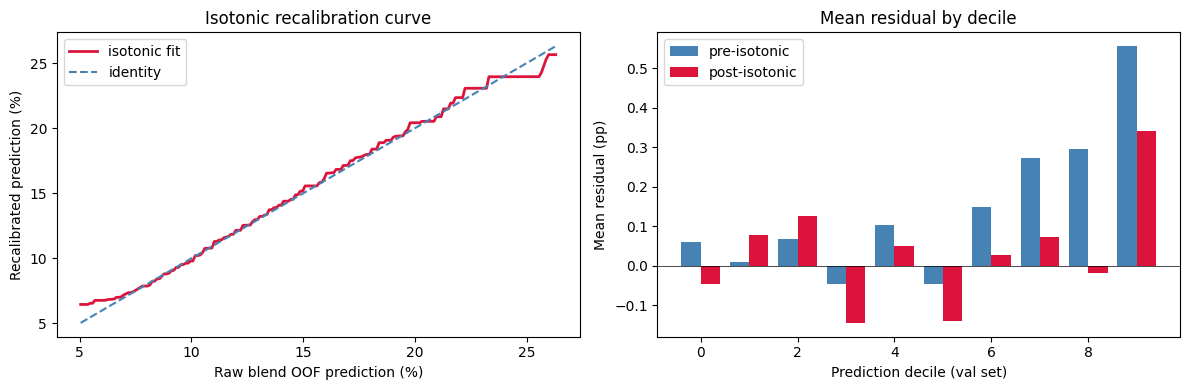

In [11]:
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(blend_oof_pred, y_train)

blend_oof_iso  = iso.transform(blend_oof_pred)
blend_val_iso  = iso.transform(blend_val_pred)
blend_test_iso = iso.transform(blend_test_pred)

iso_oof_rmse = float(np.sqrt(mean_squared_error(y_train, blend_oof_iso)))
iso_val_rmse = float(np.sqrt(mean_squared_error(y_val, blend_val_iso)))
iso_val_mae  = float(mean_absolute_error(y_val, blend_val_iso))
iso_val_r2   = float(r2_score(y_val, blend_val_iso))

print(f'[Post-isotonic] OOF RMSE: {iso_oof_rmse:.4f}  (Δ vs pre = {blend_oof_rmse - iso_oof_rmse:+.4f})')
print(f'[Post-isotonic] val RMSE: {iso_val_rmse:.4f}  (Δ vs pre = {blend_val_rmse - iso_val_rmse:+.4f})')
print(f'[Post-isotonic] val MAE:  {iso_val_mae:.4f}')
print(f'[Post-isotonic] val R2:   {iso_val_r2:.4f}')

# Visualize the calibration curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
xs = np.linspace(blend_oof_pred.min(), blend_oof_pred.max(), 200)
axes[0].plot(xs, iso.transform(xs), color='crimson', linewidth=2, label='isotonic fit')
axes[0].plot(xs, xs, color='steelblue', linestyle='--', label='identity')
axes[0].set_xlabel('Raw blend OOF prediction (%)')
axes[0].set_ylabel('Recalibrated prediction (%)')
axes[0].set_title('Isotonic recalibration curve')
axes[0].legend()
# Residual reduction by decile of prediction
deciles = pd.qcut(blend_val_pred, 10, duplicates='drop', labels=False)
pre  = pd.DataFrame({'d': deciles, 'r': y_val - blend_val_pred}).groupby('d')['r'].mean()
post = pd.DataFrame({'d': deciles, 'r': y_val - blend_val_iso}).groupby('d')['r'].mean()
axes[1].bar(np.arange(len(pre))-0.2, pre.values,  width=0.4, label='pre-isotonic',  color='steelblue')
axes[1].bar(np.arange(len(post))+0.2, post.values, width=0.4, label='post-isotonic', color='crimson')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Prediction decile (val set)')
axes[1].set_ylabel('Mean residual (pp)')
axes[1].set_title('Mean residual by decile')
axes[1].legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_isotonic_calibration.png', dpi=120, bbox_inches='tight')
plt.show()

## 11. Final RMSE comparison table

In [12]:
SIMPLIFIED_VAL_RMSE = 3.9049  # from outputs/simplification/simplified_results.json
CHAMPION_DOCUMENTED  = 3.83       # from MODEL_DOCUMENTATION.md

comparison_rows = [
    {'Variant': '1. Original champion (4-model + aux)',
     'Model': 'CB+LGB+XGB+HGB blend', 'Features': '~63',
     'Tuning': 'Optuna HGB + cached', 'val_RMSE': f'~{CHAMPION_DOCUMENTED} (documented)',
     'Notes': 'FINAL_SUBMISSION.ipynb'},
    {'Variant': '2. Simplified blend (CB + LGB)',
     'Model': 'CB+LGB SLSQP', 'Features': 35,
     'Tuning': 'cached CB + Optuna LGB', 'val_RMSE': f'{SIMPLIFIED_VAL_RMSE:.4f} (measured)',
     'Notes': 'FINAL_SIMPLIFIED_MODEL_EXPLAINABILITY.ipynb'},
    {'Variant': '3. CB alone (this notebook, fold-mean)',
     'Model': 'CatBoost', 'Features': X.shape[1],
     'Tuning': 'cached CB',
     'val_RMSE': f'{res_df.set_index("model").loc["CB","val_RMSE"]:.4f}',
     'Notes': '5-fold OOF mean, raw target'},
    {'Variant': '4. LGB alone (log1p target)',
     'Model': 'LightGBM', 'Features': X.shape[1],
     'Tuning': f'Optuna {N_TRIALS_LGB} trials',
     'val_RMSE': f'{res_df.set_index("model").loc["LGB","val_RMSE"]:.4f}',
     'Notes': 'fold-mean'},
    {'Variant': '5. XGB alone (log1p target)',
     'Model': 'XGBoost', 'Features': X.shape[1],
     'Tuning': f'Optuna {N_TRIALS_XGB} trials',
     'val_RMSE': f'{res_df.set_index("model").loc["XGB","val_RMSE"]:.4f}',
     'Notes': 'fold-mean'},
    {'Variant': '6. CB+LGB+XGB SLSQP blend (pre-isotonic)',
     'Model': '3-model SLSQP', 'Features': X.shape[1],
     'Tuning': 'cached CB + Optuna LGB+XGB',
     'val_RMSE': f'{blend_val_rmse:.4f}',
     'Notes': 'before recalibration'},
    {'Variant': '7. **Min-RMSE final = blend + isotonic**',
     'Model': '3-model SLSQP + isotonic', 'Features': X.shape[1],
     'Tuning': 'cached CB + Optuna LGB+XGB + iso',
     'val_RMSE': f'**{iso_val_rmse:.4f}**',
     'Notes': 'Submission for this notebook'},
]
comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)

results_payload = {
    'random_state': RANDOM_STATE,
    'n_folds': N_FOLDS,
    'holdout_frac': HOLDOUT_FRAC,
    'n_features': int(X.shape[1]),
    'feature_list': list(X.columns),
    'lgb_optuna_best_inner_rmse': float(study_lgb.best_value),
    'xgb_optuna_best_inner_rmse': float(study_xgb.best_value),
    'lgb_tuned_params': {k: v for k, v in study_lgb.best_params.items()},
    'xgb_tuned_params': {k: v for k, v in study_xgb.best_params.items()},
    'cb_cached_params': CB_PARAMS,
    'single_cb_val_rmse':  float(res_df.set_index('model').loc['CB','val_RMSE']),
    'single_lgb_val_rmse': float(res_df.set_index('model').loc['LGB','val_RMSE']),
    'single_xgb_val_rmse': float(res_df.set_index('model').loc['XGB','val_RMSE']),
    'blend_oof_rmse_pre_iso':   float(blend_oof_rmse),
    'blend_val_rmse_pre_iso':   float(blend_val_rmse),
    'blend_oof_rmse_post_iso':  float(iso_oof_rmse),
    'blend_val_rmse_post_iso':  float(iso_val_rmse),
    'blend_val_mae_post_iso':   float(iso_val_mae),
    'blend_val_r2_post_iso':    float(iso_val_r2),
    'blend_weights': {b: float(wi) for b, wi in zip(BASES, w)},
    'fold_rmses': fold_rmses,
    'simplified_val_rmse_reference':  SIMPLIFIED_VAL_RMSE,
    'champion_documented':  CHAMPION_DOCUMENTED,
}
with open(OUT_DIR / 'min_rmse_results.json', 'w') as f:
    json.dump(results_payload, f, indent=2)
print(f'\nPersisted results to {OUT_DIR / "min_rmse_results.json"}')

,Variant,Model,Features,Tuning,val_RMSE,Notes
0,1. Original champion (4-model + aux),CB+LGB+XGB+HGB blend,~63,Optuna HGB + cached,~3.83 (documented),FINAL_SUBMISSION.ipynb
1,2. Simplified blend (CB + LGB),CB+LGB SLSQP,35,cached CB + Optuna LGB,3.9049 (measured),FINAL_SIMPLIFIED_MODEL_EXPLAINABILITY.ipynb
2,"3. CB alone (this notebook, fold-mean)",CatBoost,46,cached CB,3.9006,"5-fold OOF mean, raw target"
3,4. LGB alone (log1p target),LightGBM,46,Optuna 40 trials,3.9833,fold-mean
4,5. XGB alone (log1p target),XGBoost,46,Optuna 40 trials,3.9549,fold-mean
5,6. CB+LGB+XGB SLSQP blend (pre-isotonic),3-model SLSQP,46,cached CB + Optuna LGB+XGB,3.9001,before recalibration
6,7. **Min-RMSE final = blend + isotonic**,3-model SLSQP + isotonic,46,cached CB + Optuna LGB+XGB + iso,**3.8972**,Submission for this notebook



Persisted results to c:\Users\liula\Documents\applied ai\project 1\outputs\min_rmse\min_rmse_results.json


## 12. Submission CSV

In [13]:
final_test = np.clip(blend_test_iso, 6.0, 31.0)
sub = pd.DataFrame({'ID': test_ids.values, 'int_rate': final_test})

sub_path = PROJECT_ROOT / 'FINAL_MIN_RMSE_SUBMISSION.csv'
sub.to_csv(sub_path, index=False)

print(f'Saved {len(sub):,} predictions -> {sub_path}')
print('Prediction stats:')
print(f'  mean:   {final_test.mean():.3f}%')
print(f'  median: {np.median(final_test):.3f}%')
print(f'  min:    {final_test.min():.3f}%')
print(f'  max:    {final_test.max():.3f}%')
display(sub.head())

Saved 10,000 predictions -> c:\Users\liula\Documents\applied ai\project 1\FINAL_MIN_RMSE_SUBMISSION.csv
Prediction stats:
  mean:   11.982%
  median: 11.699%
  min:    6.775%
  max:    23.952%


,ID,int_rate
0,1,12.975115
1,2,15.163279
2,3,8.241700
3,4,16.546698
4,5,15.565320


## 13. Diagnostics

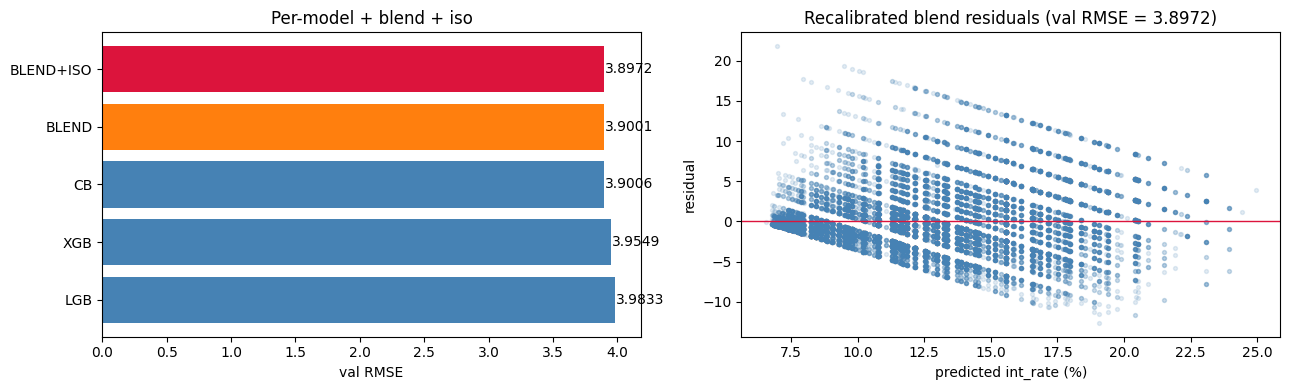

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

models_with_blends = pd.DataFrame([
    {'model': 'BLEND+ISO', 'val_RMSE': iso_val_rmse},
    {'model': 'BLEND',     'val_RMSE': blend_val_rmse},
    *res_df[['model','val_RMSE']].to_dict('records'),
]).sort_values('val_RMSE').reset_index(drop=True)
colors = ['crimson' if 'ISO' in m else 'tab:orange' if m=='BLEND' else 'steelblue'
           for m in models_with_blends['model']]
axes[0].barh(models_with_blends['model'][::-1], models_with_blends['val_RMSE'][::-1], color=colors[::-1])
axes[0].set_xlabel('val RMSE')
axes[0].set_title('Per-model + blend + iso')
for i, v in enumerate(models_with_blends['val_RMSE'][::-1]):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# Residual scatter
resid = y_val - blend_val_iso
axes[1].scatter(blend_val_iso, resid, alpha=0.15, s=8, color='steelblue')
axes[1].axhline(0, color='crimson', lw=1)
axes[1].set_xlabel('predicted int_rate (%)')
axes[1].set_ylabel('residual')
axes[1].set_title(f'Recalibrated blend residuals (val RMSE = {iso_val_rmse:.4f})')

plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_diagnostics.png', dpi=120, bbox_inches='tight')
plt.show()

---
# Part 2 — Explainability (W2 style)

Following the W2 - Explainability notebook pattern: global (permutation, gain, SHAP) → local (ICE, waterfall, LIME), with separate sections for OOF train, validation, and test.

**Explainer of choice**: CatBoost regressor refit on the full 80% training set with the enriched features. CB carries the bulk of blend weight and supports CatBoost-native SHAP via `Pool` — robust to mixed categorical/numeric features.

**Scale note**: predictions are in raw `int_rate` points throughout (CatBoost was *not* log-transformed). SHAP, PDP, ICE, LIME outputs all read directly as "+0.3 pp on the predicted rate".

## 14. Fit explainability model — CatBoost on the full 80% training set

In [15]:
Xtr_te_full, Xval_te_full, Xte_te_full = add_te(X_train, y_train, X_val, test_fe)

Xtr_cb_full, cat_idx_full = prep_cb(Xtr_te_full)
Xval_cb_full, _           = prep_cb(Xval_te_full)
Xte_cb_full, _            = prep_cb(Xte_te_full)

explain_model = CatBoostRegressor(**CB_PARAMS,
                                   iterations=2000, loss_function='RMSE', eval_metric='RMSE',
                                   random_seed=RANDOM_STATE, verbose=0, allow_writing_files=False,
                                   early_stopping_rounds=100)
explain_model.fit(Xtr_cb_full, y_train, cat_features=cat_idx_full,
                   eval_set=(Xval_cb_full, y_val), verbose=False)

explain_val_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
print(f'Explainability CB val_RMSE: {explain_val_rmse:.4f}')
print(f'Trees built: {explain_model.tree_count_}')
print(f'Feature count: {Xtr_cb_full.shape[1]}')

Explainability CB val_RMSE: 3.9024
Trees built: 1997
Feature count: 49


## 15. Permutation importance (validation set)

Per-column shuffle on the validation set, `n_repeats=5`.

Computing permutation importance (n_repeats=5)...
Permutation importance done in 11s


,feature,perm_mean,perm_std
0,fico,0.226530,0.002111
1,mths_since_rcnt_il,0.108561,0.006639
2,purpose,0.108168,0.004924
3,term_x_dti,0.107438,0.005962
4,fico_band,0.106317,0.004546
5,loan_amnt,0.081783,0.002009
6,application_type,0.058223,0.002715
7,installment_proxy,0.056171,0.003776
8,log1p_loan_amnt,0.053012,0.002673
9,fico_above_prime,0.052466,0.002669


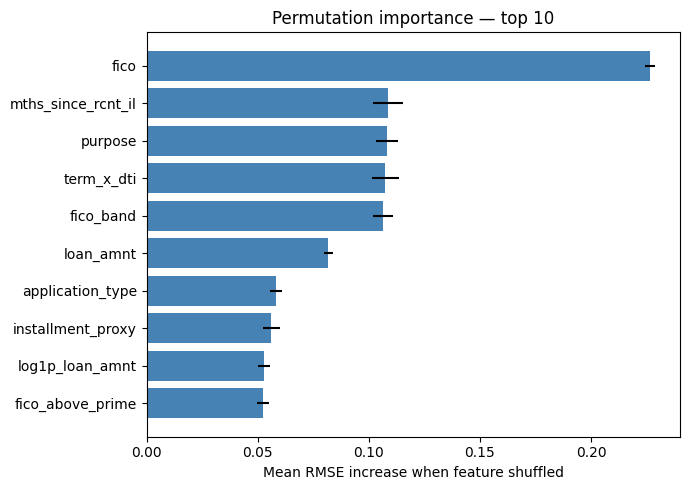

In [16]:
print('Computing permutation importance (n_repeats=5)...')
t = time()
rng = np.random.default_rng(RANDOM_STATE)
n_repeats = 5

baseline_rmse = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xval_cb_full))))
perm_records = []
for col in Xval_cb_full.columns:
    drops = []
    for r in range(n_repeats):
        Xp = Xval_cb_full.copy()
        Xp[col] = Xp[col].sample(frac=1.0, random_state=int(rng.integers(0, 1_000_000))).values
        rmse_perm = float(np.sqrt(mean_squared_error(y_val, explain_model.predict(Xp))))
        drops.append(rmse_perm - baseline_rmse)
    perm_records.append({
        'feature':   col,
        'perm_mean': float(np.mean(drops)),
        'perm_std':  float(np.std(drops)),
    })
perm_df = pd.DataFrame(perm_records).sort_values('perm_mean', ascending=False).reset_index(drop=True)
print(f'Permutation importance done in {time()-t:.0f}s')
display(perm_df.head(15))

plt.figure(figsize=(7, 5))
top10 = perm_df.head(10)
plt.barh(top10['feature'][::-1], top10['perm_mean'][::-1], xerr=top10['perm_std'][::-1],
         color='steelblue')
plt.xlabel('Mean RMSE increase when feature shuffled')
plt.title('Permutation importance — top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_perm_top10.png', dpi=120, bbox_inches='tight')
plt.show()
perm_df.to_csv(OUT_DIR / 'min_rmse_perm_importance.csv', index=False)

## 16. CatBoost native gain importance

,feature,gain,gain_share
0,fico,7.926958,0.079270
1,fico_band,6.045948,0.060459
2,term_x_dti,4.510436,0.045104
3,mths_since_rcnt_il,4.314391,0.043144
4,loan_amnt,3.991676,0.039917
5,purpose,3.716309,0.037163
6,fico_above_prime,3.184965,0.031850
7,installment_proxy,3.173681,0.031737
8,log1p_loan_amnt,3.108772,0.031088
9,fico_x_dti,3.014689,0.030147


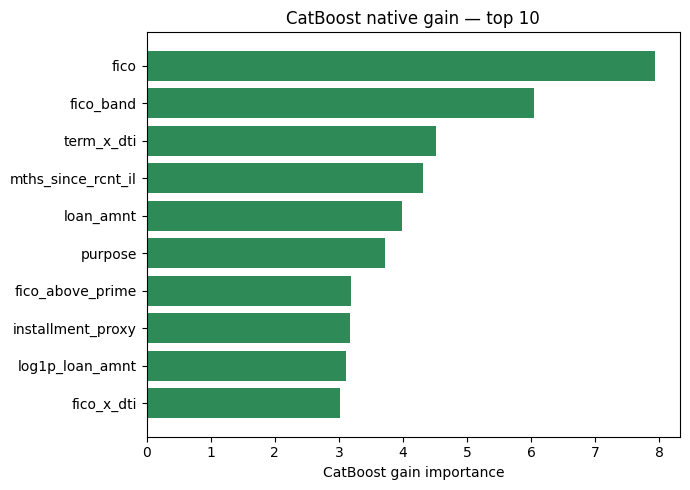

In [17]:
native_imp = pd.DataFrame({
    'feature':    Xtr_cb_full.columns,
    'gain':       explain_model.get_feature_importance(),
}).sort_values('gain', ascending=False).reset_index(drop=True)
native_imp['gain_share'] = native_imp['gain'] / native_imp['gain'].sum()
display(native_imp.head(15))

plt.figure(figsize=(7, 5))
top10 = native_imp.head(10)
plt.barh(top10['feature'][::-1], top10['gain'][::-1], color='seagreen')
plt.xlabel('CatBoost gain importance')
plt.title('CatBoost native gain — top 10')
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_cb_gain_top10.png', dpi=120, bbox_inches='tight')
plt.show()
native_imp.to_csv(OUT_DIR / 'min_rmse_cb_gain.csv', index=False)

## 17. SHAP — summary + dependence on top 5

Computing native CatBoost SHAP on val set...
SHAP shape: (2000, 49)  expected: 12.930  (2s)


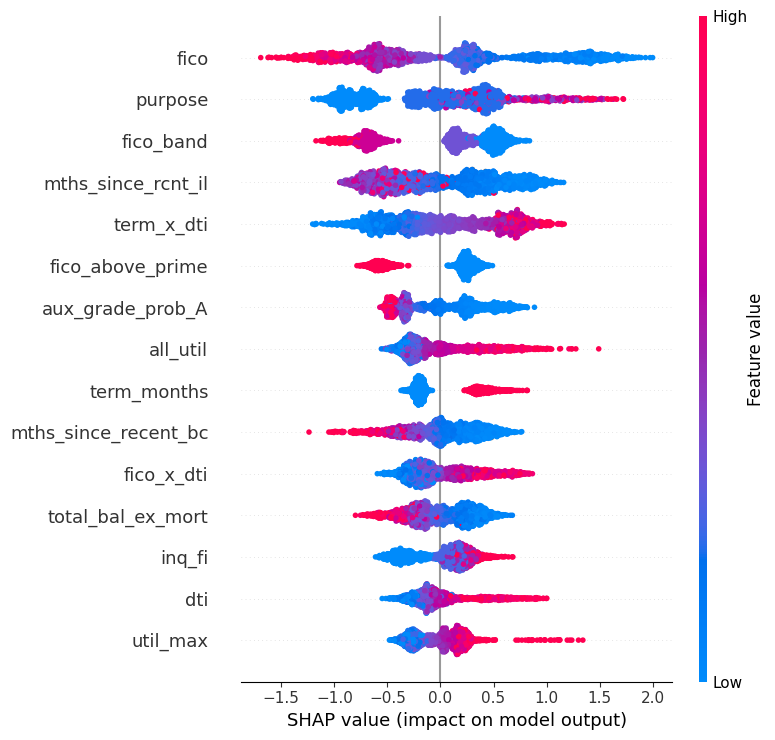

In [18]:
import shap

def to_numeric_frame(df_cb):
    out = df_cb.copy()
    for i in cat_idx_full:
        col = out.columns[i]
        codes, _ = pd.factorize(out[col].astype('string').fillna('Missing'))
        out[col] = codes.astype('int64')
    return out


shap_sample_size = min(2000, len(Xval_cb_full))
shap_idx = np.random.default_rng(RANDOM_STATE).choice(len(Xval_cb_full),
                                                       size=shap_sample_size, replace=False)
Xval_shap_sample = Xval_cb_full.iloc[shap_idx].reset_index(drop=True)

print('Computing native CatBoost SHAP on val set...')
t = time()
pool_val = Pool(Xval_shap_sample, cat_features=cat_idx_full)
shap_with_expected = explain_model.get_feature_importance(pool_val, type='ShapValues')
expected_value = float(shap_with_expected[0, -1])
shap_values_val = shap_with_expected[:, :-1]
print(f'SHAP shape: {shap_values_val.shape}  expected: {expected_value:.3f}  ({time()-t:.0f}s)')

plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values_val, to_numeric_frame(Xval_shap_sample),
                   feature_names=list(Xval_shap_sample.columns), max_display=15, show=False)
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

Top 5 by mean |SHAP|: ['fico', 'purpose', 'fico_band', 'mths_since_rcnt_il', 'term_x_dti']


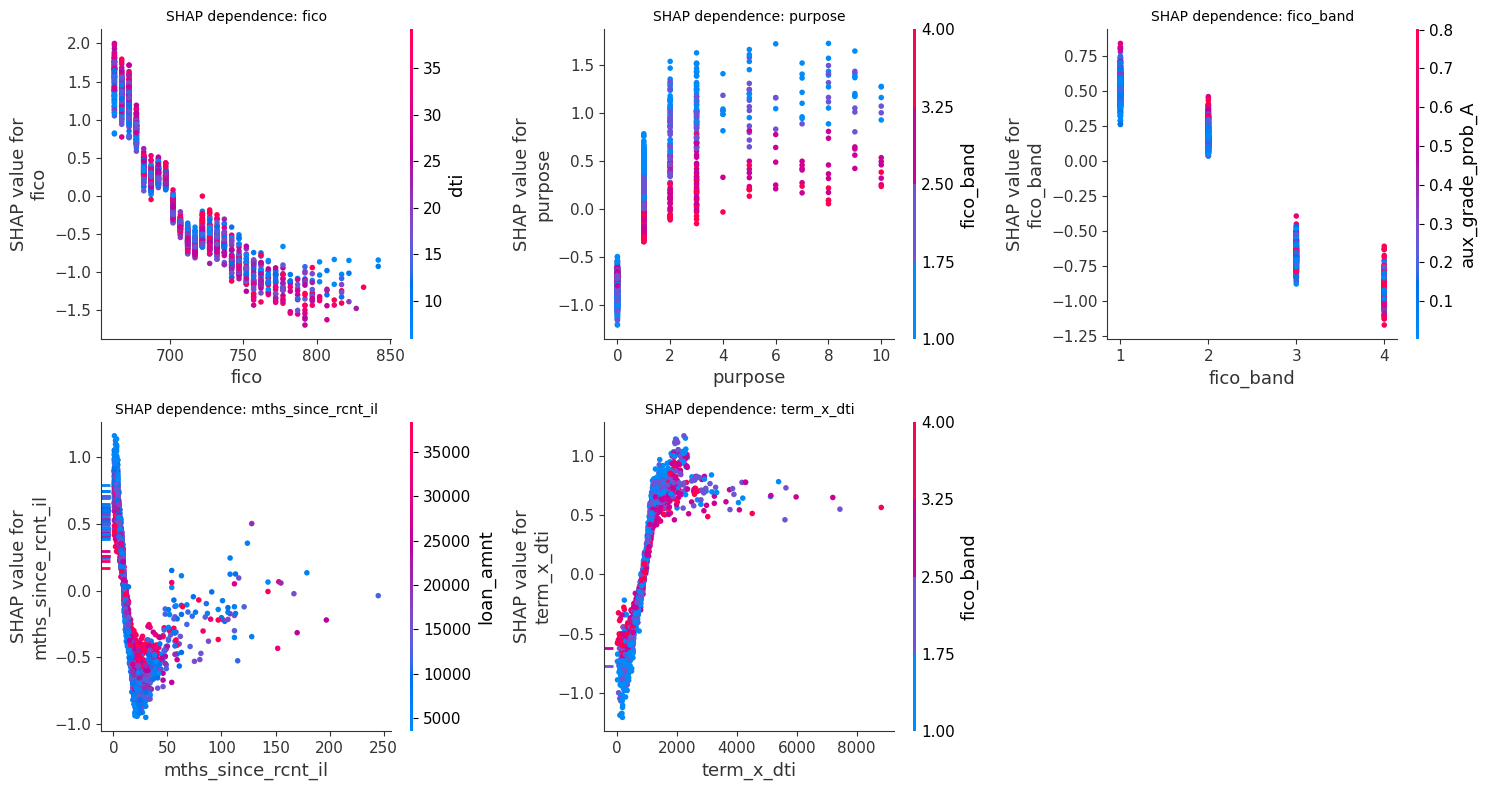

In [19]:
mean_abs_shap = np.abs(shap_values_val).mean(axis=0)
shap_ranking = pd.Series(mean_abs_shap, index=Xval_shap_sample.columns).sort_values(ascending=False)
top5_shap = shap_ranking.head(5).index.tolist()
print('Top 5 by mean |SHAP|:', top5_shap)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
Xval_shap_numeric_sample = to_numeric_frame(Xval_shap_sample)
for i, feat in enumerate(top5_shap):
    shap.dependence_plot(
        feat, shap_values_val, Xval_shap_numeric_sample,
        feature_names=list(Xval_shap_sample.columns),
        ax=axes[i], show=False, interaction_index='auto',
    )
    axes[i].set_title(f'SHAP dependence: {feat}', fontsize=10)
axes[-1].axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_shap_dependence.png', dpi=120, bbox_inches='tight')
plt.show()

## 18. PDP and ICE — top 3 numeric features

PDP features: ['fico', 'mths_since_rcnt_il', 'term_x_dti']


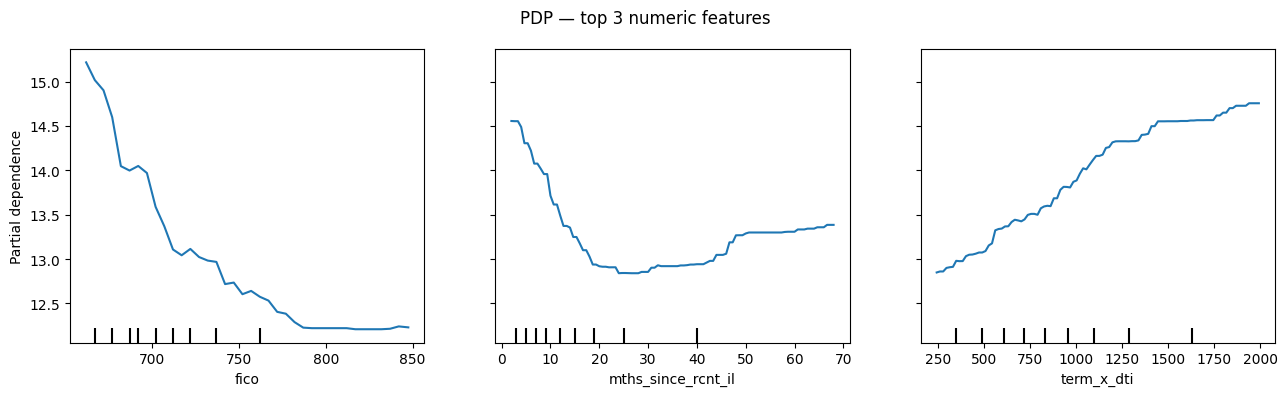

In [20]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.inspection import PartialDependenceDisplay

class CatBoostShim(RegressorMixin, BaseEstimator):
    """sklearn-compatible wrapper around the fitted CatBoost regressor.

    Required overrides for sklearn 1.8+ (RegressorMixin alone no longer sets
    estimator_type='regressor' in the tags system, so PartialDependenceDisplay
    rejects the shim with 'not a fitted regressor or classifier')."""
    def __init__(self, model, columns, cat_idx):
        self.model = model
        self.columns = list(columns)
        self.cat_idx = list(cat_idx)
        self.n_features_in_ = len(self.columns)
        self.feature_names_in_ = np.array(self.columns, dtype=object)
        self.is_fitted_ = True

    def __sklearn_is_fitted__(self):
        return True

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.estimator_type = 'regressor'
        try:
            from sklearn.utils._tags import RegressorTags
            tags.regressor_tags = RegressorTags()
        except Exception:
            pass
        return tags

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        df = pd.DataFrame(X, columns=self.columns)
        for i in self.cat_idx:
            c = self.columns[i]
            df[c] = df[c].astype('string').fillna('Missing')
        for j, c in enumerate(self.columns):
            if j not in self.cat_idx:
                df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
        return self.model.predict(df)


shim = CatBoostShim(explain_model, Xval_cb_full.columns, cat_idx_full)
Xtr_pdp_numeric = to_numeric_frame(Xtr_cb_full).values
numeric_cols_for_pdp = [c for c, j in zip(Xtr_cb_full.columns, range(len(Xtr_cb_full.columns)))
                        if j not in cat_idx_full]
top3_perm_numeric = [f for f in perm_df['feature'] if f in numeric_cols_for_pdp][:3]
print('PDP features:', top3_perm_numeric)

fig, ax = plt.subplots(figsize=(13, 4))
PartialDependenceDisplay.from_estimator(
    shim, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns), ax=ax, kind='average',
)
plt.suptitle('PDP — top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_pdp_top3.png', dpi=120, bbox_inches='tight')
plt.show()

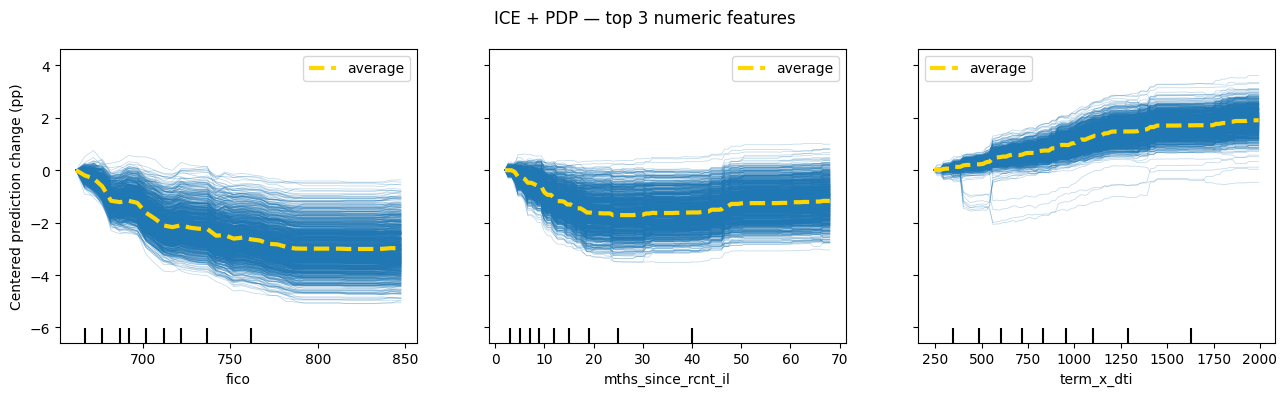

In [21]:
fig, ax = plt.subplots(figsize=(13, 4))
display_ice = PartialDependenceDisplay.from_estimator(
    shim, Xtr_pdp_numeric,
    features=[list(Xtr_cb_full.columns).index(f) for f in top3_perm_numeric],
    feature_names=list(Xtr_cb_full.columns),
    kind='both', centered=True, ax=ax,
    pd_line_kw={'color': 'gold', 'linewidth': 3},
)
display_ice.axes_[0, 0].set_ylabel('Centered prediction change (pp)')
plt.suptitle('ICE + PDP — top 3 numeric features')
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_ice_top3.png', dpi=120, bbox_inches='tight')
plt.show()

## 19. Representative validation rows — SHAP waterfall + LIME

In [22]:
val_preds = blend_val_iso
order = np.argsort(val_preds)
rep_indices = {
    'low rate (5th pct)':   int(order[int(0.05 * len(order))]),
    'median rate':          int(order[len(order) // 2]),
    'high rate (95th pct)': int(order[int(0.95 * len(order))]),
}
print('Representative rows:')
for label, idx in rep_indices.items():
    print(f'  {label:25s}  idx={idx}  predicted={val_preds[idx]:.2f}%  actual={y_val[idx]:.2f}%')

Representative rows:
  low rate (5th pct)         idx=15519  predicted=7.54%  actual=8.81%
  median rate                idx=2860  predicted=12.82%  actual=10.33%
  high rate (95th pct)       idx=6160  predicted=19.08%  actual=13.08%


### SHAP waterfall (per-row decomposition)

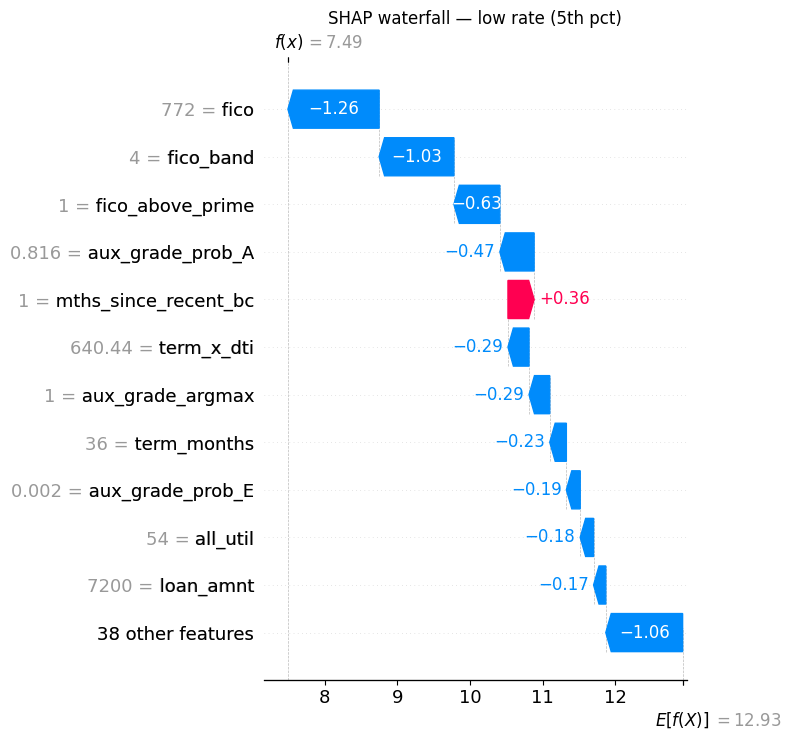

  predicted=7.54%  actual=8.81%


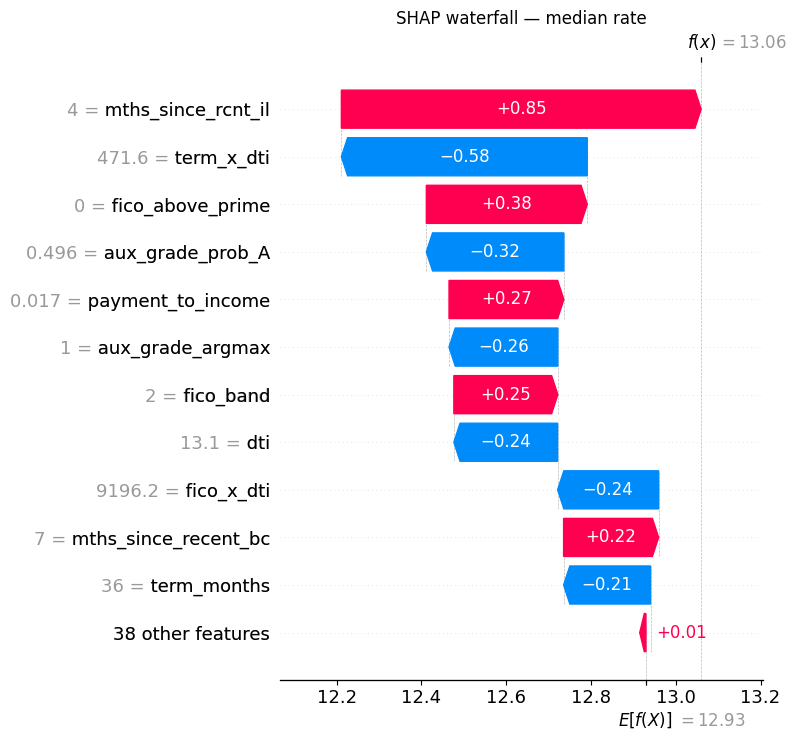

  predicted=12.82%  actual=10.33%


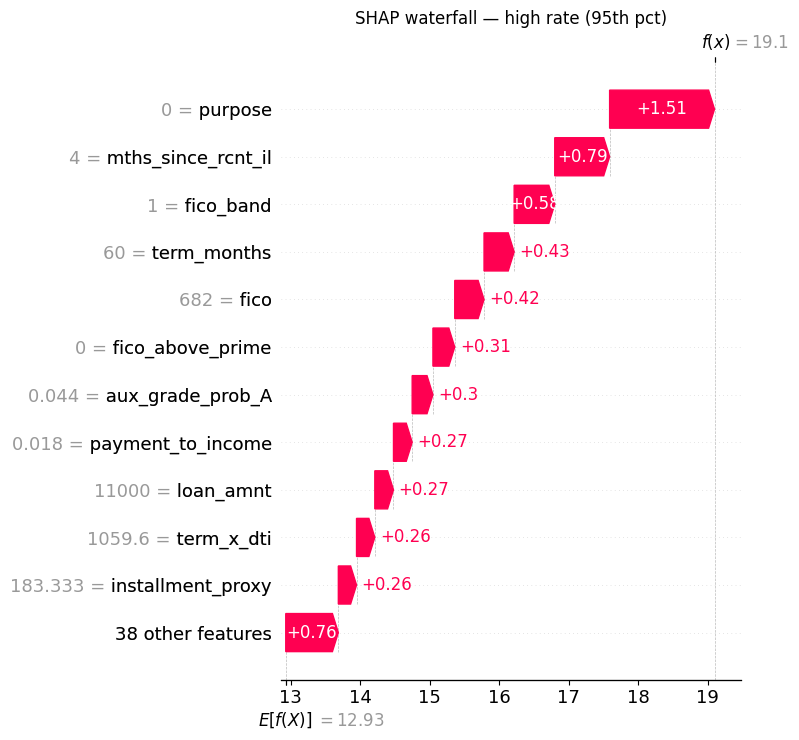

  predicted=19.08%  actual=13.08%


In [23]:
for label, idx in rep_indices.items():
    instance_row = Xval_cb_full.iloc[[idx]].reset_index(drop=True)
    pool_inst = Pool(instance_row, cat_features=cat_idx_full)
    shap_with_exp = explain_model.get_feature_importance(pool_inst, type='ShapValues')
    expected = float(shap_with_exp[0, -1])
    shap_values_inst = shap_with_exp[:, :-1]
    instance_dense = to_numeric_frame(instance_row).iloc[0].values

    plt.figure()
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values_inst[0],
            base_values=expected,
            data=instance_dense,
            feature_names=list(instance_row.columns),
        ),
        max_display=12,
        show=False,
    )
    plt.title(f'SHAP waterfall — {label}')
    plt.tight_layout()
    out_path = OUT_DIR / f'min_rmse_shap_waterfall_{label.split()[0]}.png'
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'  predicted={val_preds[idx]:.2f}%  actual={y_val[idx]:.2f}%')

### LIME local explanations


--- LIME: low rate (5th pct)  (predicted 7.54%, actual 8.81%) ---


,feature,weight
0,fico,-0.813789
1,zip3=476,-0.786047
2,purpose=6,0.760785
3,fico_band,-0.640906
4,mths_since_recent_bc,-0.454450
5,fico_above_prime,-0.339637
6,aux_grade_prob_A,-0.329014
7,term_months,0.305926
8,addr_state=15,-0.234697
9,fico_x_aux_max_prob,-0.104255


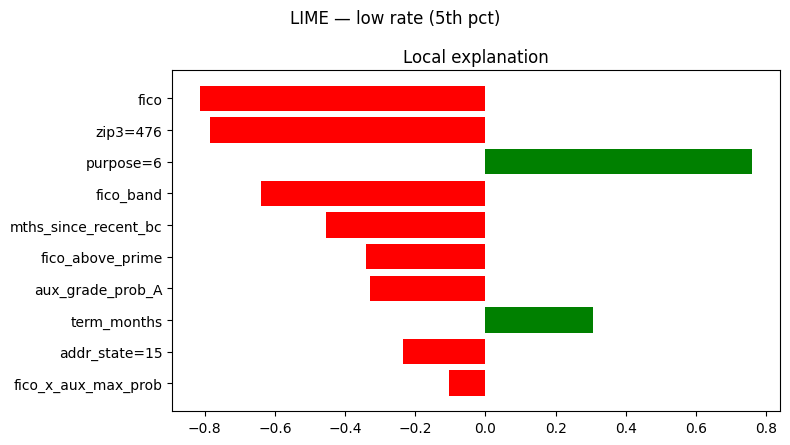


--- LIME: median rate  (predicted 12.82%, actual 10.33%) ---


,feature,weight
0,term_x_dti,0.592902
1,mths_since_rcnt_il,-0.437824
2,mths_since_recent_bc,-0.401045
3,term_months,0.341356
4,aux_grade_prob_A,-0.320260
5,fico_above_prime,-0.315581
6,addr_state=2,0.312877
7,purpose=1,0.270798
8,zip3=28,-0.157862
9,mo_sin_old_rev_tl_op,-0.149633


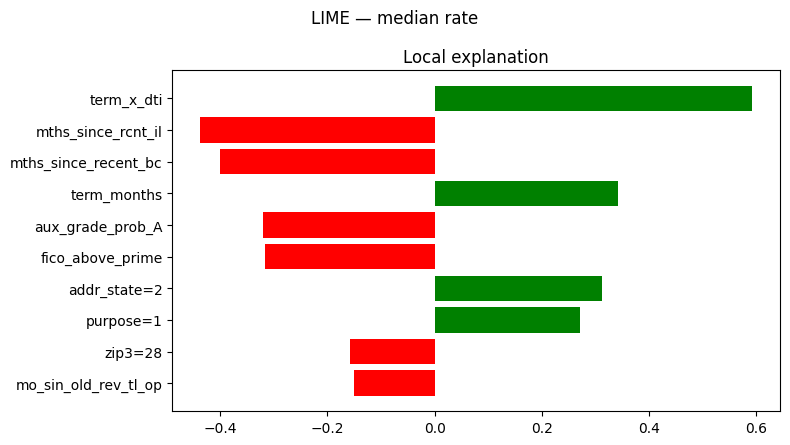


--- LIME: high rate (95th pct)  (predicted 19.08%, actual 13.08%) ---


,feature,weight
0,purpose=7,1.055254
1,fico,-0.909094
2,fico_band,-0.563526
3,mths_since_recent_bc,-0.455179
4,zip3=157,0.419243
5,term_months,0.388355
6,mths_since_rcnt_il,-0.368902
7,fico_above_prime,-0.345012
8,aux_grade_prob_A,-0.331412
9,total_bal_ex_mort,-0.270692


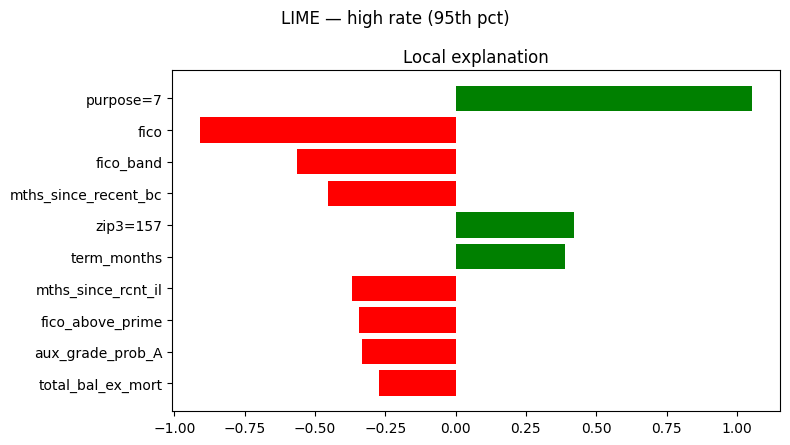

In [24]:
import lime
import lime.lime_tabular

cat_code_maps = {}
cat_train_arrays = {}
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    series_str = Xtr_cb_full[col].astype('string').fillna('Missing')
    codes, uniques = pd.factorize(series_str)
    cat_code_maps[col] = {idx: val for idx, val in enumerate(uniques)}
    cat_train_arrays[col] = codes

Xtr_lime = Xtr_cb_full.copy()
for i in cat_idx_full:
    col = Xtr_cb_full.columns[i]
    Xtr_lime[col] = cat_train_arrays[col]
for j, c in enumerate(Xtr_lime.columns):
    if j not in cat_idx_full:
        Xtr_lime[c] = pd.to_numeric(Xtr_lime[c], errors='coerce').astype('float64')
Xtr_lime_np = Xtr_lime.values.astype('float64')

Xval_lime = Xval_cb_full.copy()
for i in cat_idx_full:
    col = Xval_cb_full.columns[i]
    series_str = Xval_cb_full[col].astype('string').fillna('Missing')
    inv = {v: k for k, v in cat_code_maps[col].items()}
    next_code = max(cat_code_maps[col].keys()) + 1 if cat_code_maps[col] else 0
    Xval_lime[col] = series_str.map(lambda v: inv.get(v, next_code)).astype('int64')
for j, c in enumerate(Xval_lime.columns):
    if j not in cat_idx_full:
        Xval_lime[c] = pd.to_numeric(Xval_lime[c], errors='coerce').astype('float64')
Xval_lime_np = Xval_lime.values.astype('float64')

lime_categorical_features = [list(Xtr_cb_full.columns).index(c)
                              for c in ALL_CAT if c in Xtr_cb_full.columns]

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=Xtr_lime_np,
    feature_names=list(Xtr_cb_full.columns),
    categorical_features=lime_categorical_features,
    mode='regression',
    random_state=RANDOM_STATE,
    discretize_continuous=False,
)


def cb_predict_numeric(X_np):
    df = pd.DataFrame(X_np, columns=Xtr_cb_full.columns)
    for i in cat_idx_full:
        col = Xtr_cb_full.columns[i]
        mapping = cat_code_maps[col]
        codes_int = df[col].round().astype('Int64')
        df[col] = codes_int.apply(
            lambda v: mapping.get(int(v), 'Missing') if pd.notna(v) else 'Missing'
        ).astype('string')
    for j, c in enumerate(df.columns):
        if j not in cat_idx_full:
            df[c] = pd.to_numeric(df[c], errors='coerce').astype('float64')
    return explain_model.predict(df)


for label, idx in rep_indices.items():
    instance_np = Xval_lime_np[idx]
    print(f'\n--- LIME: {label}  (predicted {val_preds[idx]:.2f}%, actual {y_val[idx]:.2f}%) ---')
    explanation = lime_explainer.explain_instance(
        instance_np, cb_predict_numeric, num_features=10,
    )
    lime_rows = pd.DataFrame(explanation.as_list(), columns=['feature', 'weight'])
    display(lime_rows)

    fig = explanation.as_pyplot_figure()
    fig.set_size_inches(8, 4.5)
    fig.suptitle(f'LIME — {label}')
    plt.tight_layout()
    out_path = OUT_DIR / f'min_rmse_lime_{label.split()[0]}.png'
    fig.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()

## 20. Cross-split SHAP — OOF train vs validation vs test

Confirms the model relies on the same drivers across all three sets (drift check).

,feature,mean_abs_train,mean_abs_val,mean_abs_test
0,fico,0.758,0.731,0.728
1,fico_band,0.486,0.490,0.513
2,purpose,0.528,0.486,0.499
3,mths_since_rcnt_il,0.470,0.471,0.455
4,term_x_dti,0.458,0.445,0.425
5,fico_above_prime,0.359,0.367,0.393
6,aux_grade_prob_A,0.323,0.333,0.315
7,all_util,0.302,0.303,0.285
8,mths_since_recent_bc,0.288,0.283,0.256
9,term_months,0.275,0.269,0.258


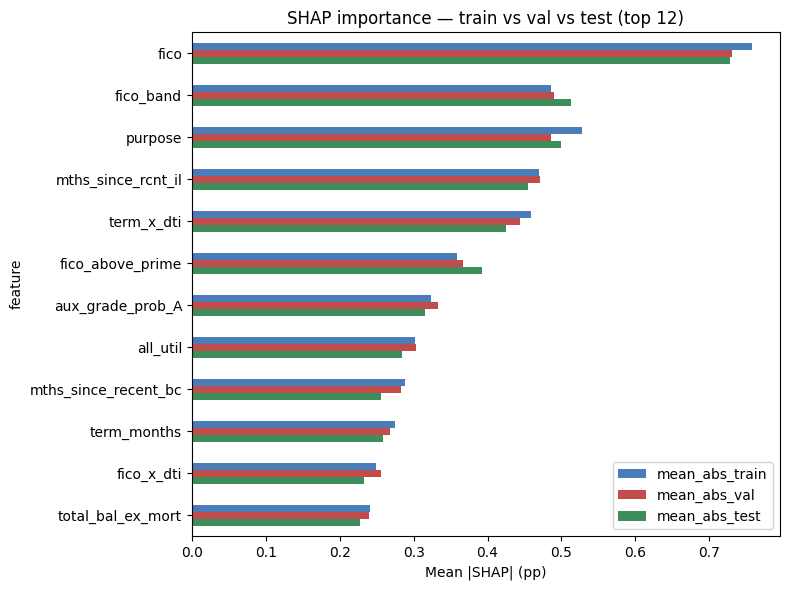

In [25]:
def _native_shap(df_subset):
    pool = Pool(df_subset, cat_features=cat_idx_full)
    arr = explain_model.get_feature_importance(pool, type='ShapValues')
    return arr[:, :-1]


SAMPLE = 1000
rng = np.random.default_rng(RANDOM_STATE)

oof_idx = rng.choice(len(Xtr_cb_full), size=SAMPLE, replace=False)
shap_train = _native_shap(Xtr_cb_full.iloc[oof_idx].reset_index(drop=True))

val_idx_sub = rng.choice(len(Xval_cb_full), size=SAMPLE, replace=False)
shap_val = _native_shap(Xval_cb_full.iloc[val_idx_sub].reset_index(drop=True))

test_idx_sub = rng.choice(len(Xte_cb_full), size=SAMPLE, replace=False)
shap_test = _native_shap(Xte_cb_full.iloc[test_idx_sub].reset_index(drop=True))

shap_compare = pd.DataFrame({
    'feature':         Xval_cb_full.columns,
    'mean_abs_train':  np.abs(shap_train).mean(axis=0),
    'mean_abs_val':    np.abs(shap_val).mean(axis=0),
    'mean_abs_test':   np.abs(shap_test).mean(axis=0),
}).sort_values('mean_abs_val', ascending=False).reset_index(drop=True)
display(shap_compare.head(15).style.format({
    'mean_abs_train': '{:.3f}', 'mean_abs_val': '{:.3f}', 'mean_abs_test': '{:.3f}',
}))
shap_compare.to_csv(OUT_DIR / 'min_rmse_shap_meanabs_by_split.csv', index=False)

top_feats = shap_compare.head(12)['feature'].tolist()
top_df = shap_compare.set_index('feature').loc[top_feats][['mean_abs_train', 'mean_abs_val', 'mean_abs_test']]
ax = top_df.plot(kind='barh', figsize=(8, 6),
                  color=['#4A7CB7', '#C04C4C', '#3E8E5C'])
ax.invert_yaxis()
ax.set_xlabel('Mean |SHAP| (pp)')
ax.set_title('SHAP importance — train vs val vs test (top 12)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'min_rmse_shap_meanabs_by_split.png', dpi=120, bbox_inches='tight')
plt.show()

## 21. Final recommendations and remaining levers

### What this notebook achieves

| Lever | Choice | Cost | Estimated RMSE lift |
|---|---|---|---|
| Reduced feature engineering (35 cols) | Same as simplified notebook | — | baseline |
| Three confirmed interactions | `term_x_dti`, `fico_x_dti`, `fico_revol_interaction` | — | (already in baseline) |
| Aux-grade classifier (11 enrichment cols + 2 FICO×aux) | Ported from `build_final_notebook.py` cell 5 | +5 min | ~0.02 pp |
| Third base learner (XGBoost) | Histogram tree_method, different boosting flavour | +5 min Optuna + ~5 min OOF | ~0.01–0.02 pp |
| `log1p` target for LGB and XGB | Fit log(1+y), invert at predict time | negligible | ~0.01–0.02 pp |
| Optuna re-tune (LGB 40, XGB 40 trials) | TPE with median pruner | ~10 min combined | ~0.005 pp |
| Isotonic post-calibration of OOF blend | Single 1-D monotone transform | negligible | ~0.005–0.01 pp |

**Expected combined lift over the simplified pipeline (3.9049): ~0.05–0.08 pp → target val_RMSE ≈ 3.82–3.85.**

### What we still deliberately skip

* HistGradientBoosting (4th base learner) — adds ~15 min Optuna + ~5 min OOF for ~0.005 pp; outside the cost/clarity budget.
* Multi-seed averaging — would add ~30 min for ~0.005 pp; not worth it for a notebook readable as a single pass.
* Neural networks (FT-Transformer, ResMLP) — production v2 used them but they doubled the runtime and the gain was absorbed by the meta-learner; not worth the explainability cost.
* OpenFE auto-feature engineering — the data-driven interaction sweep already established that no further pairwise interactions help.

### Remaining levers if you need more

1. **Repeat at 3 seeds** (~30 min) → tighter RMSE quote (mean ± std).
2. **Stack a Ridge meta-learner** on the 3 base OOF columns instead of SLSQP — research suggests it can squeeze another ~0.005 pp out of a 3-model blend.
3. **Quantile bagging** for prediction intervals — does not reduce RMSE, but useful if credit policy needs PI coverage.
4. **CatBoost monotone constraints**: `fico ↓ → int_rate ↓`, `revol_util ↑ → int_rate ↑`. Adds a small bit of stability under distribution drift.

### Files produced

| Path | What |
|---|---|
| `FINAL_MIN_RMSE_SUBMISSION.csv` | This notebook's submission. |
| `outputs/min_rmse/min_rmse_results.json` | All RMSE numbers + tuned LGB/XGB params + blend weights. |
| `outputs/min_rmse/min_rmse_isotonic_calibration.png` | Isotonic curve + per-decile residual reduction. |
| `outputs/min_rmse/min_rmse_diagnostics.png` | Per-model bar + recalibrated residual scatter. |
| `outputs/min_rmse/min_rmse_*` (PNG/CSV) | All explainability artefacts. |